In [153]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

In [154]:
from model.metrics import logloss,evaluate_binary_classifier
from model.gradients import logloss_sigmoid_grad
from model.utils import *
from model.activations import sigmoid
import matplotlib.pyplot as plt

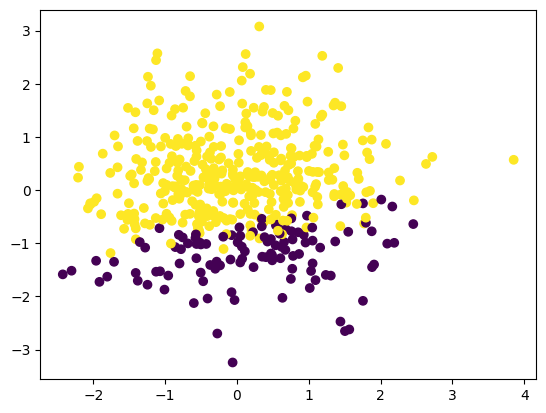

In [155]:
# Sample Code for generating datasets
size = 500
dim=2
noise_bound = 0.2

seed = 42
np.random.seed(seed)

X,y,W = generate_linear_dataset(size,dim,noise_bound=noise_bound,is_reg=False)
plt.scatter(X[:,1],X[:,2],c=y)

In [156]:
# loading data
loaded_data = np.load(f'data/logistic_data/logistic_data_D.npz')

X = loaded_data['X_data']
y = loaded_data['y_data']
W = loaded_data['W_data']

# Show the size of data
print(f"X size : {X.shape}, y size : {y.shape}")

# Make sure size and dim correct.
size = X.shape[0]
dim = X.shape[1]-1

X size : (8000, 6), y size : (8000,)


50. Training loss: 0.4210863364107006, Val loss:0.42389318391426317
100. Training loss: 0.4006650658061348, Val loss:0.4052693942293411
150. Training loss: 0.3833104146387553, Val loss:0.38946444714134726
200. Training loss: 0.36844391326627834, Val loss:0.3759451207657198
250. Training loss: 0.35560590258631664, Val loss:0.36428763531349373
300. Training loss: 0.34443109894084123, Val loss:0.354154961784246
350. Training loss: 0.33462857869617535, Val loss:0.3452784421002676
400. Training loss: 0.32596580182229623, Val loss:0.33744318725215144
450. Training loss: 0.31825604822090914, Val loss:0.33047660104180177
500. Training loss: 0.31134861624599863, Val loss:0.3242394100832966
550. Training loss: 0.30512120261559816, Val loss:0.31861866833458574
600. Training loss: 0.29947398138187187, Val loss:0.31352230201213016
650. Training loss: 0.29432499674933427, Val loss:0.3088748500410424
700. Training loss: 0.28960656875428886, Val loss:0.3046141303741866
750. Training loss: 0.2852624794

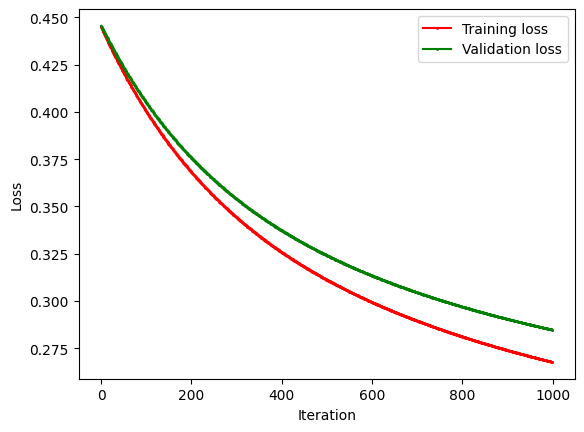

In [157]:
# Train the model
from model.linear_model import LinearModel

seed = 42 # do not change the seed
np.random.seed(seed)

# Setting loss function, gradient, and activation function.
loss_fn = logloss
act_fn = sigmoid
grad_fn = logloss_sigmoid_grad

# Split dataset to train dataset and validation dataset
X_train,y_train,X_val,y_val = get_train_val(X,y)

# Setting model and starting training
model = LinearModel(dim,False,loss_fn,grad_fn,act_fn)
model.fit(X_train,y_train,lr=0.01,n_iteration =1000,val_ratio=0.2)

In [158]:
# Get the Prediction
y_val_pred = model.predict(X_val)

Logistic Regression Evaluation
Accuracy  : 0.9263
Precision : 0.9394
Recall    : 0.9266
F1-score  : 0.9330


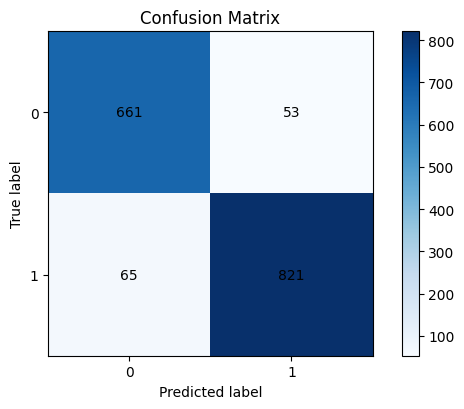

{'Accuracy': 0.92625,
 'Precision': 0.9393592677345538,
 'Recall': 0.9266365688487584,
 'F1-score': 0.9329545454545455}

In [159]:
# Evaluation
# Please complete the evaluate_binary_classifier in the model/metrics.py by the sklearn package.
evaluate_binary_classifier(y_true=y_val,y_pred=y_val_pred,title='Logistic Regression Evaluation')

Plot validation set and decision boundary

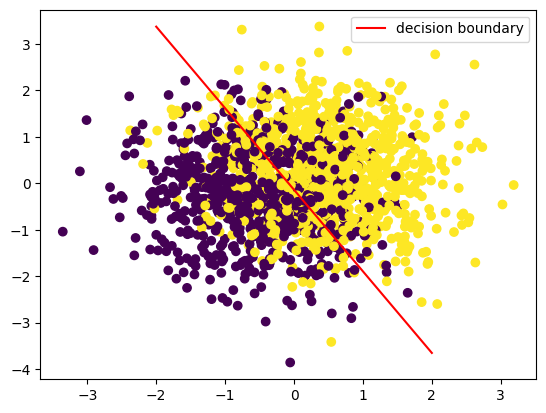

In [160]:
# Plot
plt.scatter(X_val[:,1],X_val[:,2],c=y_val)

ex1 = np.linspace(-2, 2, 100)
ex2 = -(model.W[1] * ex1 + model.W[0]) / model.W[2]

plt.plot(ex1, ex2, color='r', label='decision boundary')
plt.legend()
plt.show()